# Task 4: Custom Gradient Descent Optimizers with Momentum, RMSprop, and Adam
Implementation using PyTorch tensor mathematics only (no torch.optim).

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [2]:
# Synthetic nonlinear dataset
N=1000
X=torch.randn(N,2)
y=((X[:,0]**2+X[:,1])>0).float().view(-1,1)


In [3]:
class MLP:
    def __init__(self):
        self.W1=torch.randn(2,16)*0.5
        self.b1=torch.zeros(1,16)
        self.W2=torch.randn(16,1)*0.5
        self.b2=torch.zeros(1,1)

    def forward(self,X):
        self.Z1=X@self.W1+self.b1
        self.A1=torch.relu(self.Z1)
        self.Z2=self.A1@self.W2+self.b2
        return torch.sigmoid(self.Z2)

    def backward(self,X,y,pred):
        m=X.shape[0]
        dZ2=(pred-y)/m
        dW2=self.A1.T@dZ2
        db2=dZ2.sum(0,keepdim=True)

        dA1=dZ2@self.W2.T
        dZ1=dA1*(self.Z1>0).float()

        dW1=X.T@dZ1
        db1=dZ1.sum(0,keepdim=True)

        return [dW1,db1,dW2,db2]

    def params(self):
        return [self.W1,self.b1,self.W2,self.b2]


In [4]:
class Momentum:
    def __init__(self,params,lr=0.01,beta=0.9):
        self.lr=lr
        self.beta=beta
        self.v=[torch.zeros_like(p) for p in params]

    def step(self,params,grads):
        for i,(p,g) in enumerate(zip(params,grads)):
            self.v[i]=self.beta*self.v[i]-self.lr*g
            p+=self.v[i]


class RMSprop:
    def __init__(self,params,lr=0.001,beta=0.9,eps=1e-8):
        self.lr=lr
        self.beta=beta
        self.eps=eps
        self.s=[torch.zeros_like(p) for p in params]

    def step(self,params,grads):
        for i,(p,g) in enumerate(zip(params,grads)):
            self.s[i]=self.beta*self.s[i]+(1-self.beta)*(g*g)
            p-=self.lr*g/(torch.sqrt(self.s[i])+self.eps)


class Adam:
    def __init__(self,params,lr=0.001,b1=0.9,b2=0.999,eps=1e-8):
        self.lr=lr
        self.b1=b1
        self.b2=b2
        self.eps=eps
        self.m=[torch.zeros_like(p) for p in params]
        self.v=[torch.zeros_like(p) for p in params]
        self.t=0

    def step(self,params,grads):
        self.t+=1
        for i,(p,g) in enumerate(zip(params,grads)):
            self.m[i]=self.b1*self.m[i]+(1-self.b1)*g
            self.v[i]=self.b2*self.v[i]+(1-self.b2)*(g*g)

            mh=self.m[i]/(1-self.b1**self.t)
            vh=self.v[i]/(1-self.b2**self.t)

            p-=self.lr*mh/(torch.sqrt(vh)+self.eps)


In [5]:
def train(opt_name):
    model=MLP()

    if opt_name=="Momentum":
        opt=Momentum(model.params())

    elif opt_name=="RMSprop":
        opt=RMSprop(model.params())

    else:
        opt=Adam(model.params())

    history=[]

    for epoch in range(300):

        pred=model.forward(X)

        loss=-(y*torch.log(pred+1e-8)+(1-y)*torch.log(1-pred+1e-8)).mean()

        grads=model.backward(X,y,pred)

        opt.step(model.params(),grads)

        history.append(loss.item())

    return history

mom=train("Momentum")
rms=train("RMSprop")
adam=train("Adam")


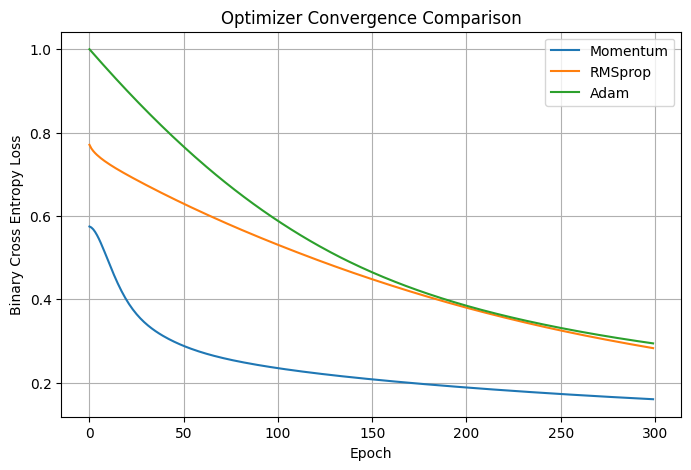

In [6]:
plt.figure(figsize=(8,5))
plt.plot(mom,label="Momentum")
plt.plot(rms,label="RMSprop")
plt.plot(adam,label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Optimizer Convergence Comparison")
plt.grid(True)
plt.legend()
plt.show()
